In [1]:
import numpy as np
import pandas as pd
import math 
import matplotlib.pyplot as plt
from skimpy.core.parameters import ParameterValuePopulation, load_parameter_population
from skimpy.utils.tensor import Tensor
from skimpy.io.yaml import load_yaml_model

In [2]:
fccref1=pd.read_csv('./../data/FCCEXP_ref1.csv',sep=';')
fccref2=pd.read_csv('./../data/FCCEXP_ref2.csv',sep=';')
fccref3=pd.read_csv('./../data/FCCEXP_ref3.csv',sep=';')
fccref4=pd.read_csv('./../data/FCCEXP_ref4.csv',sep=';')
fccref1=fccref1.iloc[:,1:]
fccref2=fccref2.iloc[:,1:]
fccref3=fccref3.iloc[:,1:]
fccref4=fccref4.iloc[:,1:]
parameter_population = load_parameter_population('./../data/pruned_parameters2032025.hdf5')
calculated_parameters=pd.DataFrame(data=[dict(parameter_population._data[parameter_population._index[i]]) for i in parameter_population._index])
ind=parameter_population._index
calculated_parameters.index=ind
fccref1=np.array(fccref1)
fccref2=np.array(fccref2)
fccref3=np.array(fccref3)
fccref4=np.array(fccref4)

In [3]:
reactions_indexes = {0:29,1:52,2:50,3:19,4:73,5:28,6:55,7:61,8:49,9:54,10:36,11:63,12:64,13:71,14:69,15:72,16:14,17:3,18:37,
                   19:7,20:67,21:25,22:42,23:57,24:43,25:38,26:40}
knockouts_indexes = {0:52,1:55,2:61,3:54,4:63,5:64,6:71,7:69}
maximum_number= 216
number_function = []
for model in range(0,len(fcccalc[0,0,:])):
    number=0
    for (knock1,knock2) in knockouts_indexes.items():
        for (reaction1,reaction2) in reactions_indexes.items():
            fccexp = [fccref1[reaction1,knock1],fccref2[reaction1,knock1],fccref3[reaction1,knock1],fccref4[reaction1,knock1]]
            if min(fccexp)<fcccalc[reaction2,knock2,model]<max(fccexp):
                number=number+1
    number_function.append(number)
number_function=np.array(number_function)/maximum_number

number_function_matrix = pd.DataFrame(data=number_function,index=[calculated_parameters.index],columns=['number_function'])
number_function_matrix.to_csv('number_function_matrix.csv')      


In [4]:
number_function_matrix

,number_function
"1,1",0.675926
"1,2",0.634259
"1,4",0.662037
"1,8",0.634259
"3,1",0.671296
...,...
"999,0",0.657407
"999,1",0.629630
"999,4",0.703704
"999,5",0.638889


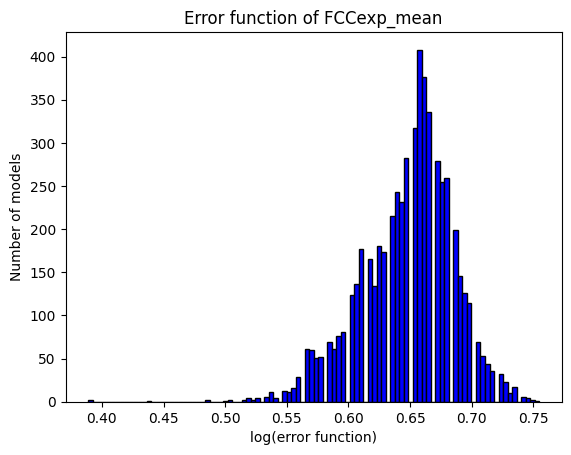

In [7]:
plt.hist(number_function, bins=100, color='blue', edgecolor='black')

# Add titles and labels
plt.title("Error function of FCCexp_mean")
plt.xlabel("log(error function)")
plt.ylabel("Number of models")

# Show the plot
plt.show()
#plt.savefig("error_function_ref4.png") 